In [378]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, SGDRegressor, ElasticNet

A partir de un archivo de excel crea un dataframe

In [379]:
# xl_file = pd.ExcelFile("Raton1 388X_.xlsx")
# dfs = {sheet_name: xl_file.parse(sheet_name) 
#          for sheet_name in xl_file.sheet_names}
# data = np.array(dfs['GnRH 10nM 40seg'])

In [380]:
# np.save('data.npy', data)
data = np.load('data.npy')

In [381]:
rs = np.random.RandomState(0)
# data_ = data.transpose() - data.transpose().mean(axis=0)
data_ = data[:,1:] # probablemente quita el identificador de los datos, dejando los demas campos.
data_.shape
# data_ /= data_.std(axis=0)

(999, 507)

Muestra la forma de los datos (como se comportan las células en estímulos de tiempo)

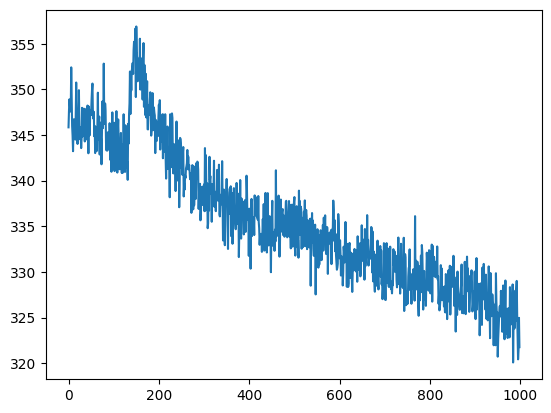

In [382]:
plt.plot(np.array(range(len(data_[:, 15]))).reshape(-1, 1), data_[:, 15])
ax = plt.gca()
plt.show()

Normaliza los datos

In [383]:
norm_data = np.zeros(data_.shape) # crea un arreglo con zeros en la forma de los datos

for i in range(data_.shape[1]): 
    reg = ElasticNet().fit(np.array(range(len(data_[:, i]))).reshape(-1, 1), data_[:, i])
    #reg = svm.SVR().fit(np.array(range(len(data_[:, i]))).reshape(-1, 1), data_[:, i])
    res = reg.predict(np.array(range(len(data_[:, i]))).reshape(-1, 1))
    norm_data[:, i] = data_[:, i] - res
    min_data = min(norm_data[:, i])
    max_data = max(norm_data[:, i])
    #norm_data[:, i] = data_[:, i]
    #norm_data[:, i] = norm_data[:, i] - min_data
    #norm_data[:, i] = norm_data[:, i] / min_data
    norm_data[:, i] = (norm_data[:, i] - min_data) / (max_data - min_data)

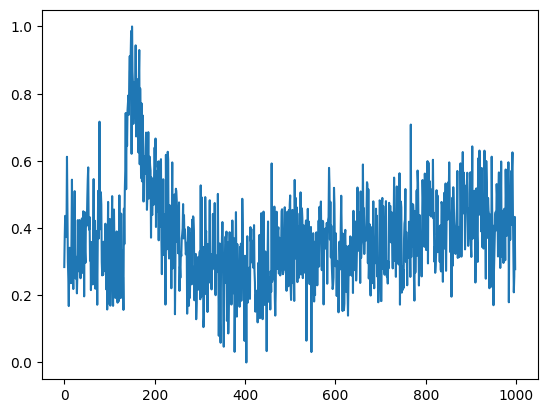

<Figure size 1000x600 with 0 Axes>

In [384]:
plt.plot(np.array(range(len(norm_data[:, 15]))).reshape(-1, 1), norm_data[:, 15])
ax = plt.gca()
plt.figure(figsize=(10,6))
plt.show()

In [385]:
norm_data.shape

(999, 507)

Encontrar picos

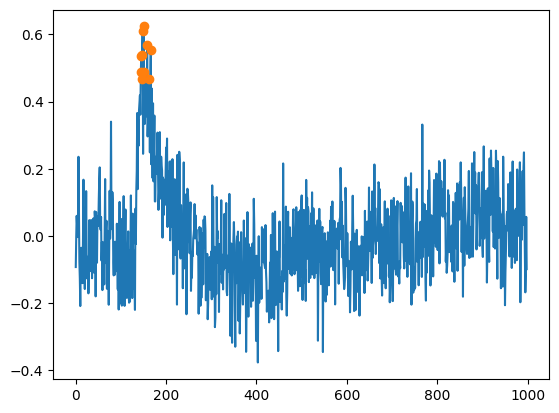

In [386]:
from sklearn.covariance import EllipticEnvelope

pico_norm_data = norm_data[:,15]

reg = ElasticNet().fit(np.array(range(len(pico_norm_data))).reshape(-1, 1), pico_norm_data)
res = reg.predict(np.array(range(len(pico_norm_data))).reshape(-1, 1))

new_data = pico_norm_data - res
clf = EllipticEnvelope(random_state=0, contamination=0.01).fit(new_data.reshape(-1, 1))
y_pred = clf.predict(new_data.reshape(-1, 1))
#y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(pico_norm_data))).reshape(-1, 1), pico_norm_data - res)
plt.plot(np.array(range(len(pico_norm_data))).reshape(-1, 1)[y_res], (pico_norm_data - res)[y_res], "o")

plt.show()

Análisis de correlaciones

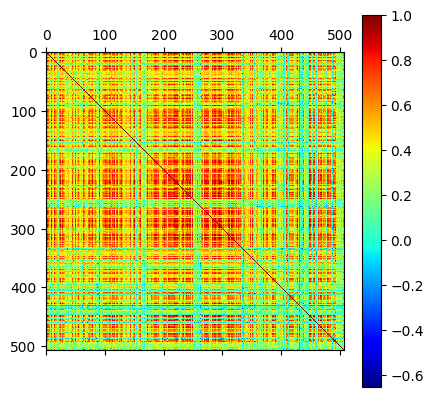

In [387]:
df = pd.DataFrame(norm_data)
corr1 = df.corr(method='pearson')
plt.matshow(corr1, cmap='jet')
plt.colorbar()
plt.show()

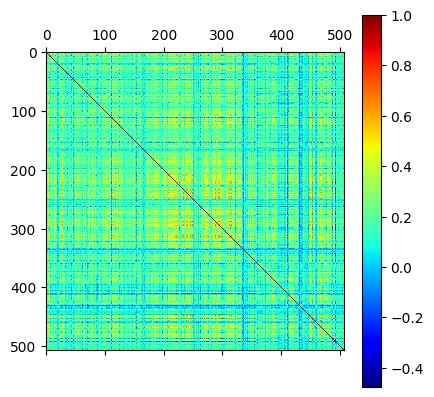

In [388]:
df = pd.DataFrame(norm_data)
corr = df.corr(method='kendall')
plt.matshow(corr, cmap='jet')
plt.colorbar()
plt.show()

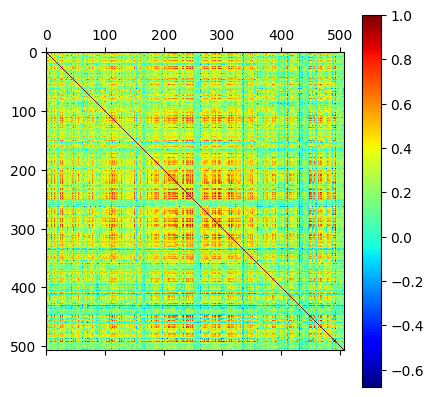

In [389]:
df = pd.DataFrame(norm_data)
corr = df.corr(method='spearman')
plt.matshow(corr, cmap='jet')
plt.colorbar()
plt.show()

In [390]:
def plot_corr(df,size=10):
    '''Plot a graphical correlation matrix for a dataframe.

    Input:
        df: pandas DataFrame
        size: vertical and horizontal size of the plot'''
    
    %matplotlib inline
    import matplotlib.pyplot as plt

    # Compute the correlation matrix for the received dataframe
    corr_func = df.corr()
    
    # Plot the correlation matrix
    fig, ax = plt.subplots(figsize=(size, size))
    # cax = ax.matshow(corr, cmap='RdYlGn')
    cax = ax.matshow(corr_func, cmap='jet')
    # plt.xticks(range(len(corr.columns)), corr.columns, rotation=90);
    # plt.yticks(range(len(corr.columns)), corr.columns);
    
    # Add the colorbar legend
    cbar = fig.colorbar(cax, ticks=[-1, 0, 1], aspect=40, shrink=.8)

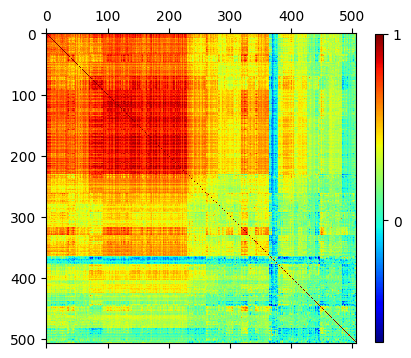

In [391]:
import scipy.cluster.hierarchy as sch
df = pd.DataFrame(norm_data)
X = corr1.values
d = sch.distance.pdist(X)   # vector of ('55' choose 2) pairwise distances
L = sch.linkage(d, method='complete')
# ind = sch.fcluster(L, 0.2*d.max(), 'distance')
ind = sch.fcluster(L, 50, criterion='maxclust')
columns = [df.columns.tolist()[i] for i in list((np.argsort(ind)))]
df = df.reindex(columns, axis=1)

plot_corr(df, size=5)

In [392]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [393]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(norm_data.transpose())
clustering.labels_.shape

(507,)

Crea un dendograma

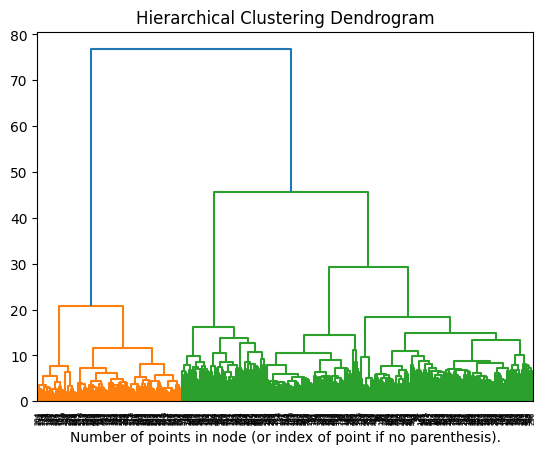

In [394]:
import math
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(clustering, truncate_mode="none", count_sort='none', show_contracted='true')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

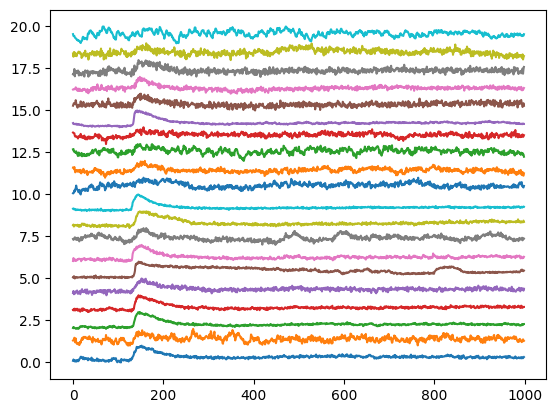

In [395]:
for i in range(20):
    plt.plot(np.array(range(len(norm_data[:, i]))).reshape(-1, 1), norm_data[:, i] + i)
ax = plt.gca()
plt.show()